# Brand value (income split) and the FIFA-added brand value

**Review notebook** for the project's brand valuation: `brand_value_dcf_v2`, the ISO 10668 income approach with an earnings split (ADR-0045), whose role of brand is the brand contribution factor from `brand_value_dominance_v1` (ADR-0044); and the FIFA-added brand value, the FIFA-specific uplift (ADR-0043) applied to it. Cross-checks (share × market cap, published valuations, comparison routes) are shown at the end for review only; the dashboard shows income-split values exclusively. It follows the human-review standard in `AGENTS.md`.

> **Status: planning valuation, not audited.** Every assumption and every input figure is listed below. The brand contribution factor is a reading of share-price data that the data cannot pin down (section 5.6); quote values with their ranges.

*How to use:* run all cells. Read-only unless `RUN_REBUILD = True`. Narrative numbers are computed from current outputs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: re-runs the valuation chain (a few minutes: placebo draws)
    for module in ["srmp.experiments.stock_brand_response_v2", "srmp.experiments.brand_value_dominance_v1",
                   "srmp.experiments.brand_value_dcf_v2", "srmp.experiments.sponsorship_total_return_v3",
                   "srmp.experiments.valuation_routes_v1"]:
        subprocess.run([sys.executable, "-m", module], check=True)
import yaml

E = "data/curated/experimental/"
D, V = E + "brand_value_dominance_v1/", E + "brand_value_dcf_v2/"
SOURCES = [
    "config/experiments/brand_value_dcf_v2.yaml", "config/experiments/brand_value_dominance_v1.yaml",
    "data/reference/lenovo_annual_financials.csv", "data/reference/lenovo_quarterly_financials.csv",
    "data/reference/lenovo_market_valuation_reference.csv", "data/staged/market/market_prices_daily.parquet",
    V + "brand_value_dcf_manifest.json", V + "economic_profit_forecast.parquet", V + "sensitivity_grid.parquet",
    D + "brand_value_dominance_manifest.json", D + "dominance_weights.parquet", D + "stability.parquet",
    E + "sponsorship_exposure_timing_v1/exposure_timing_manifest.json",
    E + "valuation_routes_v1/valuation_routes.parquet",
]
stamp_sources(SOURCES)
dcf = json.loads(Path(V + "brand_value_dcf_manifest.json").read_text())
dom = json.loads(Path(D + "brand_value_dominance_manifest.json").read_text())
cfg = yaml.safe_load(Path("config/experiments/brand_value_dcf_v2.yaml").read_text())
prim, W, base, used = dcf["primary_result"], dcf["discount_rate"], dcf["base_year"], dcf["inputs_used"]
forecast = pd.read_parquet(V + "economic_profit_forecast.parquet")
bn = lambda v: f"US${v/1000:,.2f}bn"   # inputs are US$ millions

REVIEW_SOURCES={"config/experiments/brand_value_dcf_v2.yaml": "4987c3d46be2c5385199bdc1d8a188f0933940f247e8c5c03ac2ce4323611678", "config/experiments/brand_value_dominance_v1.yaml": "ca3e30680fb263d5be13cd941ce5f0e3ea999512a060ab1bceaad81bb93c86af", "data/reference/lenovo_annual_financials.csv": "f8f58adc1d053fded7398b23d1041c6ffb52cb9b2bac06bdd6829a6d21f69bee", "data/reference/lenovo_quarterly_financials.csv": "e418999c1ccf5806c79b09a2b7819069636b3a83e2949a259c84a66b52e4b1ab", "data/reference/lenovo_market_valuation_reference.csv": "c117f44cb4bf68fadfe1809a7d86fb14e96d012d4f7828bdaf6ee1e8b088a6f5", "data/staged/market/market_prices_daily.parquet": "ef3564d75cbc2bdfccac96ca8a150dee3a15da80ee218841f6c4fc2cf99e47c1", "data/curated/experimental/brand_value_dcf_v2/brand_value_dcf_manifest.json": "3439c9bfc41fc7c1b5543b2873d2d10bc990827df89e3074213761ff44063a01", "data/curated/experimental/brand_value_dcf_v2/economic_profit_forecast.parquet": "3fbf7d0b3421d852483cfe55736e7caba060c1fb2e59a39

## 1. Question and purpose

**Questions.** (a) What is the Lenovo brand worth, as the present value of its share of the profit Lenovo earns above its cost of capital? (b) How much of that value did the FIFA sponsorship add?

**Why it matters.** This is the money translation of the sponsorship's brand effect for the client. Every input and assumption is shown so the value can be audited and challenged.

**Objective supported.** Monetisation of the sponsorship's brand uplift.

## 2. Evidence and inputs

| Input | Source | Label |
|---|---|---|
| Revenue, operating profit, profit before tax, taxation (FY24/25, FY25/26) | Lenovo results release FY2025/26 (`pl_source_url`) | **observed** |
| Total equity, minority interest, total debt, cash, short-term investments | Balance sheet via stockanalysis.com (`balance_sheet_source_url`) | **observed** (secondary source) |
| Quarterly revenue FY22/23–FY25/26 | Lenovo quarterly results | **observed** |
| US 10-year Treasury yield; Lenovo, ACWI and USD/HKD daily closes | Yahoo Finance chart API (`data/staged/market`) | **observed** |
| Ordinary shares outstanding | Lenovo FY2025/26 annual report | **observed** |
| Equity risk premium, debt spread, terminal growth, growth fade, constant margin and capital turnover | Valuation convention / project config | **assumed** |
| Brand contribution factor | Dominance analysis of weekly abnormal returns (`brand_value_dominance_v1`) | **estimated** |
| FIFA-specific uplift | `sponsorship_exposure_timing_v1` (ADR-0043) | **estimated** |

### 2.1 Balance sheet and income statement used

In [2]:
annual = pd.read_csv("data/reference/lenovo_annual_financials.csv")
cols = ["fiscal_year", "period_end", "revenue_usd_m", "operating_profit_usd_m", "profit_before_tax_usd_m", "taxation_usd_m",
        "total_equity_usd_m", "minority_interest_usd_m", "total_debt_usd_m", "cash_usd_m", "short_term_investments_usd_m"]
show = annual[cols].set_index("fiscal_year").T
show.index = ["Period end", "Revenue (US$m)", "Operating profit (US$m)", "Profit before tax (US$m)", "Taxation (US$m)",
              "Total equity (US$m)", "Minority interest (US$m)", "Total debt (US$m)", "Cash (US$m)", "Short-term investments (US$m)"]
display(show)
for _, r in annual.iterrows():
    md(f"*{r['fiscal_year']}:* P&L — {r['pl_source_url']} · balance sheet — {r['balance_sheet_source_url']}")

fiscal_year,FY24/25,FY25/26
Period end,2025-03-31,2026-03-31
Revenue (US$m),69077,83075
Operating profit (US$m),2164,3262
Profit before tax (US$m),1481,2670
Taxation (US$m),19,510
Total equity (US$m),6660,8444
Minority interest (US$m),1138,1356
Total debt (US$m),5733,5156
Cash (US$m),4728,4887
Short-term investments (US$m),58.24,52.44


*FY24/25:* P&L — https://investor.lenovo.com/en/financial/results/press_2526_q4.pdf · balance sheet — https://stockanalysis.com/quote/hkg/0992/financials/balance-sheet/

*FY25/26:* P&L — https://investor.lenovo.com/en/financial/results/press_2526_q4.pdf · balance sheet — https://stockanalysis.com/quote/hkg/0992/financials/balance-sheet/

### 2.2 Revenue history used for the growth path

In [3]:
fy = pd.Series(used["fiscal_year_revenue_usd_m"]).rename("Fiscal-year revenue (US$m, sum of four quarters)")
display(fy.to_frame().style.format("{:,.0f}"))

,"Fiscal-year revenue (US$m, sum of four quarters)"
FY22/23,"61,948"
FY23/24,"56,864"
FY24/25,"69,077"
FY25/26,"83,074"


### 2.3 Market data used for the discount rate

In [4]:
display(pd.DataFrame([
    ("US 10-year Treasury yield", f"{W['risk_free']:.2%}", W["risk_free_date"]),
    ("Lenovo share price (0992.HK)", f"HK${W['share_price_hkd']:.2f}", W["equity_value_date"]),
    ("USD/HKD", f"{W['usd_hkd']:.4f}", W["equity_value_date"]),
    ("Ordinary shares outstanding", f"{W['shares']:,}", "FY2025/26 annual report"),
    ("Equity market value (price × shares ÷ FX)", bn(W["equity_value_usd_m"]), W["equity_value_date"]),
    ("Total debt (book)", bn(W["debt_usd_m"]), base["fiscal_year"]),
    ("Beta benchmark and window", f"{W['beta_benchmark']}, {W['beta_weeks']} weekly USD returns", f"to {W['equity_value_date']}"),
], columns=["Input", "Value", "Date / source"]).style.hide(axis="index"))
ref_px = pd.read_csv("data/reference/lenovo_market_valuation_reference.csv").iloc[-1]
md(f"The share price moved from HK${ref_px['closing_price_hkd']:.2f} at {ref_px['reference_date']} (annual report) to HK${W['share_price_hkd']:.2f}; it enters only the "
   f"debt/equity weights of the WACC, where the debt weight is {W['weight_debt']:.1%}.")

Input,Value,Date / source
US 10-year Treasury yield,5.30%,2026-10-05
Lenovo share price (0992.HK),HK$35.92,2026-10-05
USD/HKD,7.8470,2026-10-05
Ordinary shares outstanding,"12,404,659,302",FY2025/26 annual report
Equity market value (price × shares ÷ FX),US$56.78bn,2026-10-05
Total debt (book),US$5.16bn,FY25/26
Beta benchmark and window,"ACWI, 104 weekly USD returns",to 2026-10-05


The share price moved from HK$9.15 at 2026-03-31 (annual report) to HK$35.92; it enters only the debt/equity weights of the WACC, where the debt weight is 8.3%.

## 3. Method and formulas

**Base year.** From the latest audited year:

$$m = \frac{\text{operating profit}}{\text{revenue}}, \quad \tau = \frac{\text{taxation}}{\text{profit before tax}}, \quad IC_0 = \text{equity} + \text{debt} - \text{cash} - \text{short-term investments}.$$

*In words:* the operating margin, the effective tax rate, and the capital tied up in operations (equity and debt, net of cash).

**Forecast (5 years).** Revenue grows at $g_1$ (the trailing three-fiscal-year CAGR) fading linearly to $g_\infty$; capital grows with revenue (constant turnover $R/IC$):

$$\text{NOPAT}_t = R_t\, m\, (1-\tau), \qquad \text{EP}_t = \text{NOPAT}_t - \text{WACC} \cdot IC_{t-1}.$$

*In words:* economic profit is after-tax operating profit less a fair return on the capital used.

**Discount rate (CAPM WACC).** $k_e = r_f + \beta\, \text{ERP}$ with $\beta = 0.67\,\beta_{raw} + 0.33$ (Blume) against ACWI; $k_d = (r_f + s)(1-\tau)$; $\text{WACC} = (1-w_d)\,k_e + w_d\, k_d$, $w_d = D/(D+E)$ at market equity value.

**Income split and brand value.** With the brand contribution factor $\rho$,

$$BE_t = \rho\, \text{EP}_t, \qquad BV = \sum_{t=1}^{5} \frac{BE_t}{(1+\text{WACC})^t} + \frac{\rho\,\big[\text{NOPAT}_5 (1+g_\infty) - \text{WACC}\cdot IC_5\big]}{(\text{WACC}-g_\infty)\,(1+\text{WACC})^5}.$$

*In words:* the brand is worth the present value of its share of economic profit: five forecast years plus a growing perpetuity.

**Brand contribution factor.** $\rho = \operatorname{sign}(\hat\beta_{brand})\, D_{brand} / \sum_{g\ne market} D_g$: the brand's general-dominance share of the weekly abnormal-return movement explained by Lenovo-specific drivers (ADR-0044).

**FIFA-added brand value.** $\Delta BV = \varepsilon\, u\, BV$ with $u$ the FIFA-specific uplift in brand share and $\varepsilon = 1$; equivalently, $u\,\varepsilon$ of every year's branded earnings.

## 4. Calculation path

| Step | Code | Configuration | Output |
|---|---|---|---|
| Brand contribution factor | `srmp/experiments/brand_value_dominance_v1.py` (`_lenovo_specific`, `_placebos`) | `config/experiments/brand_value_dominance_v1.yaml` | `brand_value_dominance_v1/` |
| Base year, growth, WACC, forecast, brand value, sensitivities | `srmp/experiments/brand_value_dcf_v2.py` (`_wacc`, `_forecast`, `_brand_value`) | `config/experiments/brand_value_dcf_v2.yaml` | `brand_value_dcf_v2/` |
| FIFA-specific uplift | `srmp/experiments/sponsorship_exposure_timing_v1.py` | `config/experiments/sponsorship_exposure_timing_v1.yaml` | `sponsorship_exposure_timing_v1/` |
| Dashboard figures | `frontend/scripts/build_eroi_data.py` | – | `frontend/data/eroi-data.js` |

## 5. Results

### 5.1 Base year

In [5]:
ic = used["invested_capital_components_usd_m"]
display(pd.DataFrame([
    ("Revenue", f"US${base['revenue']:,.0f}m"),
    ("Operating margin = operating profit / revenue", f"{base['operating_margin']:.2%}"),
    ("Effective tax rate = taxation / profit before tax", f"{base['tax_rate']:.1%}"),
    ("Invested capital = equity + debt − cash − short-term investments",
     f"{ic['total_equity']:,.0f} + {ic['total_debt']:,.0f} − {ic['less_cash']:,.0f} − {ic['less_short_term_investments']:,.0f} = US${base['invested_capital']:,.0f}m"),
    ("After-tax return on invested capital", f"{base['return_on_invested_capital']:.1%}"),
], columns=[f"{base['fiscal_year']} item", "Value"]).style.hide(axis="index"))

FY25/26 item,Value
Revenue,"US$83,075m"
Operating margin = operating profit / revenue,3.93%
Effective tax rate = taxation / profit before tax,19.1%
Invested capital = equity + debt − cash − short-term investments,"8,444 + 5,156 − 4,887 − 52 = US$8,661m"
After-tax return on invested capital,30.5%


### 5.2 Growth and discount rate

In [6]:
a, b = used["start_growth_years"]
display(pd.DataFrame([
    ("Start growth = (revenue %s / revenue %s)^(1/3) − 1" % (b, a), f"{dcf['revenue_growth']['start']:.2%}"),
    ("Terminal growth (assumed)", f"{dcf['revenue_growth']['terminal']:.1%}"),
    ("Risk-free rate", f"{W['risk_free']:.2%}"),
    ("Raw beta → Blume-adjusted beta", f"{W['raw_beta']:.2f} → {W['beta']:.2f}"),
    ("Equity risk premium (assumed)", f"{W['equity_risk_premium']:.1%}"),
    ("Cost of equity", f"{W['cost_of_equity']:.2%}"),
    ("Pre-tax debt spread (assumed) → after-tax cost of debt", f"{W['pre_tax_debt_spread']:.1%} → {W['after_tax_cost_of_debt']:.2%}"),
    ("Debt weight", f"{W['weight_debt']:.1%}"),
    ("WACC", f"{W['wacc']:.2%}"),
], columns=["Item", "Value"]).style.hide(axis="index"))

Item,Value
Start growth = (revenue FY25/26 / revenue FY22/23)^(1/3) − 1,10.28%
Terminal growth (assumed),3.0%
Risk-free rate,5.30%
Raw beta → Blume-adjusted beta,1.05 → 1.03
Equity risk premium (assumed),5.0%
Cost of equity,10.47%
Pre-tax debt spread (assumed) → after-tax cost of debt,1.5% → 5.50%
Debt weight,8.3%
WACC,10.06%


### 5.3 Economic-profit forecast and branded earnings

Year,Growth,Revenue,NOPAT,Opening IC,Capital charge,Economic profit,Branded earnings,Discount factor,PV branded
1,10.3%,"91,611","2,910","8,661",871,"2,039",484,0.909,440
2,8.5%,"99,359","3,156","9,550",960,"2,196",521,0.826,430
3,6.6%,"105,954","3,366","10,358","1,042","2,324",552,0.750,414
4,4.8%,"111,060","3,528","11,046","1,111","2,417",574,0.682,391
5,3.0%,"114,392","3,634","11,578","1,164","2,469",586,0.619,363


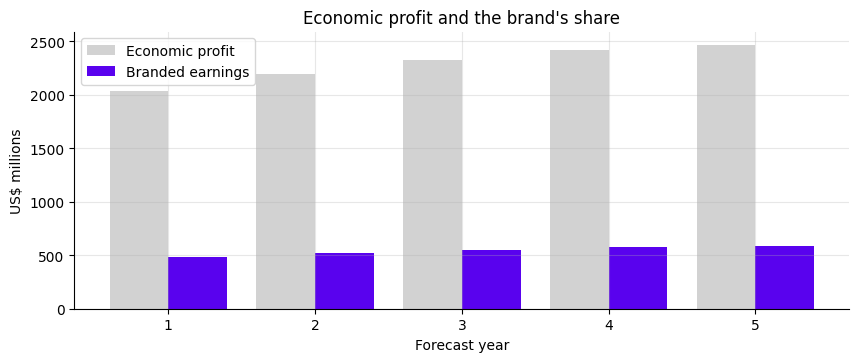

**Table 6 and Figure 1.** US$ millions. Brand contribution factor ρ = 23.7%. Present value of explicit branded earnings US$2.04bn; terminal value US$5.30bn (72% of the total).

In [7]:
f = forecast.copy()
f["pv_branded_usd_m"] = f["branded_earnings_usd_m"] * f["discount_factor"]
display(f[["year", "revenue_growth", "revenue_usd_m", "nopat_usd_m", "opening_invested_capital_usd_m", "capital_charge_usd_m",
           "economic_profit_usd_m", "branded_earnings_usd_m", "discount_factor", "pv_branded_usd_m"]].rename(columns={
    "year": "Year", "revenue_growth": "Growth", "revenue_usd_m": "Revenue", "nopat_usd_m": "NOPAT", "opening_invested_capital_usd_m": "Opening IC",
    "capital_charge_usd_m": "Capital charge", "economic_profit_usd_m": "Economic profit", "branded_earnings_usd_m": "Branded earnings",
    "discount_factor": "Discount factor", "pv_branded_usd_m": "PV branded"})
    .style.format({"Growth": "{:.1%}", "Discount factor": "{:.3f}", **{c: "{:,.0f}" for c in ["Revenue", "NOPAT", "Opening IC", "Capital charge", "Economic profit", "Branded earnings", "PV branded"]}}).hide(axis="index"))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(f["year"] - 0.2, f["economic_profit_usd_m"], width=0.4, color="#D2D2D2", label="Economic profit")
ax.bar(f["year"] + 0.2, f["branded_earnings_usd_m"], width=0.4, color="#5902EE", label="Branded earnings")
ax.set_xlabel("Forecast year"); ax.set_ylabel("US$ millions"); ax.set_title("Economic profit and the brand's share"); ax.legend(); plt.show()
md(f"**Table 6 and Figure 1.** US$ millions. Brand contribution factor ρ = {prim['role_of_brand']:.1%}. Present value of explicit branded earnings "
   f"{bn(prim['explicit_pv_usd_m'])}; terminal value {bn(prim['terminal_pv_usd_m'])} ({prim['terminal_share_of_value']:.0%} of the total).")

### 5.4 Brand value and its sensitivity

In [8]:
grid = pd.read_parquet(V + "sensitivity_grid.parquet")
g0 = dcf["revenue_growth"]["terminal"]
heat = grid[grid["role_of_brand"].str.startswith("grid") & np.isclose(grid["terminal_growth"], g0)].pivot(index="role_value", columns="wacc", values="brand_value_usd_m") / 1000
heat.index = [f"{v:.0%}" for v in heat.index]; heat.columns = [f"WACC {c:.1%}" for c in heat.columns]
display(heat.style.format("US${:.1f}bn"))
own = grid[grid["role_of_brand"].eq("brand_contribution_factor")]
md(f"**Lenovo brand value: {bn(prim['brand_value_usd_m'])}** (discounted economic profit {bn(dcf['economic_profit_pv_usd_m'])} × {prim['role_of_brand']:.1%}). "
   f"WACC ±1 point and terminal growth ±0.5 point give {bn(own['brand_value_usd_m'].min())} to {bn(own['brand_value_usd_m'].max())}; "
   f"the factor's 90% bootstrap range gives {bn(dcf['by_role_definition']['factor_bootstrap_p05']['brand_value_usd_m'])} to "
   f"{bn(dcf['by_role_definition']['factor_bootstrap_p95']['brand_value_usd_m'])}. **Table 7** is brand value (US$bn) by factor and WACC at the base terminal growth.")

,WACC 9.1%,WACC 10.1%,WACC 11.1%
10%,US$3.8bn,US$3.1bn,US$2.6bn
15%,US$5.7bn,US$4.6bn,US$3.9bn
20%,US$7.5bn,US$6.2bn,US$5.2bn
25%,US$9.4bn,US$7.7bn,US$6.5bn
30%,US$11.3bn,US$9.3bn,US$7.7bn
35%,US$13.2bn,US$10.8bn,US$9.0bn


**Lenovo brand value: US$7.34bn** (discounted economic profit US$30.91bn × 23.7%). WACC ±1 point and terminal growth ±0.5 point give US$5.79bn to US$9.71bn; the factor's 90% bootstrap range gives US$-3.06bn to US$21.19bn. **Table 7** is brand value (US$bn) by factor and WACC at the base terminal growth.

### 5.5 Where the brand contribution factor comes from

In [9]:
wts = pd.read_parquet(D + "dominance_weights.parquet")
display(wts[["group", "dominance_r2", "share_of_explained", "share_of_lenovo_specific"]].rename(columns={
    "group": "Driver group", "dominance_r2": "Dominance (R² points)", "share_of_explained": "Share of all explained movement",
    "share_of_lenovo_specific": "Share of Lenovo-specific explained movement"})
    .style.format({"Dominance (R² points)": "{:.4f}", "Share of all explained movement": "{:.1%}", "Share of Lenovo-specific explained movement": "{:.1%}"}, na_rep="— (set aside)").hide(axis="index"))
coef = dom["coefficients"]["brand_full_sample"]["brand"]
md(f"**Table 8.** {dom['samples']['brand_weeks']} weeks of Lenovo log returns on market factors, PC category demand, Lenovo events and the Brand Index innovation. "
   f"Brand coefficient {coef['coefficient']:+.5f} (robust s.e. {coef['robust_se']:.5f}, t = {coef['coefficient']/coef['robust_se']:+.2f}).")

Driver group,Dominance (R² points),Share of all explained movement,Share of Lenovo-specific explained movement
market,0.1640,91.2%,— (set aside)
category_demand,0.0042,2.3%,26.4%
lenovo_events,0.0079,4.4%,49.8%
brand,0.0038,2.1%,23.7%


**Table 8.** 164 weeks of Lenovo log returns on market factors, PC category demand, Lenovo events and the Brand Index innovation. Brand coefficient +0.00298 (robust s.e. 0.00255, t = +1.17).

### 5.6 How firm is the factor? Stability and placebo

In [10]:
stab = pd.read_parquet(D + "stability.parquet")
display(stab[["check", "weeks", "r2", "brand_share"]].rename(columns={"check": "Check", "weeks": "Weeks", "r2": "Model R²", "brand_share": "Brand contribution factor"})
        .style.format({"Model R²": "{:.3f}", "Brand contribution factor": "{:.1%}"}).hide(axis="index"))
P = dom["placebo"]
md(f"**Table 9.** Across samples and control sets the factor ranges {dom['stability_summary']['brand_share_min']:.0%}–{dom['stability_summary']['brand_share_max']:.0%}; "
   f"its 90% bootstrap range is {dom['values']['brand_share_90pct'][0]:.0%} to {dom['values']['brand_share_90pct'][1]:.0%}. "
   f"A random series in the brand's place obtains a median {P['random_series']['median']:.0%} (probability {P['random_series']['probability_at_or_above_actual']:.2f} of reaching the brand's share); "
   f"the time-shifted brand series {P['time_shifted_brand']['median']:.0%} ({P['time_shifted_brand']['probability_at_or_above_actual']:.2f}). "
   "The factor is a reading of the market data, not a statistically identified quantity.")

Check,Weeks,Model R²,Brand contribution factor
sample 2022-01-01 to 2024-10-14,62,0.363,3.3%
sample 2024-10-15 to 2026-12-31,102,0.167,20.4%
sample 2022-01-01 to 2025-12-31,125,0.360,25.9%
without category_demand,164,0.176,28.0%
without lenovo_events,164,0.167,41.5%
with earnings_weeks as an extra Lenovo-specific group,164,0.180,26.8%
with momentum as an extra Lenovo-specific group,164,0.180,23.6%
brand measured as delta_brand_index,164,0.178,22.2%


**Table 9.** Across samples and control sets the factor ranges 3%–42%; its 90% bootstrap range is -10% to 69%. A random series in the brand's place obtains a median 21% (probability 0.47 of reaching the brand's share); the time-shifted brand series 23% (0.50). The factor is a reading of the market data, not a statistically identified quantity.

### 5.7 FIFA-added brand value

In [11]:
u, added = prim["fifa_specific_uplift_pct"], prim["fifa_added_brand_value_usd_m"]
display(pd.DataFrame([
    ("Primary (FIFA-specific)", u["primary"], added["primary"]),
    ("95% band, low", u["statistical_band_95_low"], added["statistical_band_95_low"]),
    ("95% band, high", u["statistical_band_95_high"], added["statistical_band_95_high"]),
    ("Ceiling: whole gap, same weeks", u["attribution_band_upper"], added["attribution_band_upper"]),
], columns=["Case", "Uplift (% brand share)", "FIFA-added brand value (US$m)"])
    .style.format({"Uplift (% brand share)": "{:+.2f}%", "FIFA-added brand value (US$m)": "{:,.0f}"}).hide(axis="index"))
flow = f[["year"]].assign(**{"FIFA share of branded earnings (US$m)": prim["elasticity_to_brand_share"] * u["primary"] / 100 * f["branded_earnings_usd_m"]})
display(flow.rename(columns={"year": "Year"}).style.format({"FIFA share of branded earnings (US$m)": "{:,.1f}"}).hide(axis="index"))
md(f"**Tables 10–11.** FIFA-added brand value = uplift × {bn(prim['brand_value_usd_m'])}; as a flow, {flow.iloc[0, 1]:.1f} to {flow.iloc[-1, 1]:.1f} US$m of branded earnings a year in the forecast years.")

Case,Uplift (% brand share),FIFA-added brand value (US$m)
Primary (FIFA-specific),+4.53%,333
"95% band, low",+2.00%,147
"95% band, high",+7.07%,519
"Ceiling: whole gap, same weeks",+7.34%,538


Year,FIFA share of branded earnings (US$m)
1,22.0
2,23.6
3,25.0
4,26.0
5,26.6


**Tables 10–11.** FIFA-added brand value = uplift × US$7.34bn; as a flow, 22.0 to 26.6 US$m of branded earnings a year in the forecast years.

### 5.8 Cross-checks (review only; not shown on the dashboard)

In [12]:
x = dcf["cross_check"]
display(pd.DataFrame([
    ("This study: income split (primary)", prim["brand_value_usd_m"], prim["role_of_brand"]),
    ("This study: factor × mean post-announcement market cap", x["market_cap_route_usd_m"], x["role_of_brand_implied"]["market_cap_route_usd_m"]),
    ("Brand Finance China 500 2025 (royalty relief)", x["brand_finance_2025_usd_m"], x["role_of_brand_implied"]["brand_finance_2025_usd_m"]),
    ("Interbrand Best Global Brands 2015", x["interbrand_2015_usd_m"], x["role_of_brand_implied"]["interbrand_2015_usd_m"]),
], columns=["Valuation", "Brand value (US$m)", "Implied share of discounted economic profit"])
    .style.format({"Brand value (US$m)": "{:,.0f}", "Implied share of discounted economic profit": "{:.1%}"}).hide(axis="index"))
routes = pd.read_parquet(E + "valuation_routes_v1/valuation_routes.parquet")
routes = routes[routes["route"] != "industry_claimed_media_value"]   # P1: media value is never money
display(routes[["route", "link_identified", "value_unit", "value_at_measured_level"]].rename(columns={
    "route": "Comparison route (total effect)", "link_identified": "Link identified", "value_unit": "Unit", "value_at_measured_level": "Value"})
    .style.format({"Value": "{:,.1f}"}, na_rep="—").hide(axis="index"))
others = [v for k, v in x["role_of_brand_implied"].items()]
md(f"**Tables 12–13.** The other valuations imply a brand share of discounted economic profit of {min(others):.0%}–{max(others):.0%}, against the factor's {prim['role_of_brand']:.0%}"
   f"{' (the income split is the highest)' if prim['role_of_brand'] > max(others) else ''}. "
   "The comparison routes use the total effect and are not statistically identified; they are kept for review only (ADR-0045).")

Valuation,Brand value (US$m),Implied share of discounted economic profit
This study: income split (primary),"7,339",23.7%
This study: factor × mean post-announcement market cap,"5,036",16.3%
Brand Finance China 500 2025 (royalty relief),"5,663",18.3%
Interbrand Best Global Brands 2015,"4,100",13.3%


Comparison route (total effect),Link identified,Unit,Value
market_implied_equity_v3,False,"full-contract equity value, US$m","2,079.7"
market_implied_annual_earnings,False,"annual earnings-equivalent, US$m",37.3
direct_profit_margin,False,"annual adjusted net income, US$m (trailing-four-quarter revenue)",61.9
relief_from_royalty,False,"annual after-tax royalty saving per 1bp of royalty rate, US$m",—
announcement_event_study,False,"gross event equity value, US$m",306.2


**Tables 12–13.** The other valuations imply a brand share of discounted economic profit of 13%–18%, against the factor's 24% (the income split is the highest). The comparison routes use the total effect and are not statistically identified; they are kept for review only (ADR-0045).

## 6. Interpretation

In [13]:
md(f"""- **Brand value:** Lenovo earns about US${forecast['economic_profit_usd_m'].iloc[0]:,.0f}m a year above its {W['wacc']:.1%} cost of capital, rising with revenue;
  discounted, that economic profit is worth {bn(dcf['economic_profit_pv_usd_m'])}. With the brand accounting for {prim['role_of_brand']:.1%} of it, the brand is worth
  **{bn(prim['brand_value_usd_m'])}** (WACC and growth range {bn(own['brand_value_usd_m'].min())}–{bn(own['brand_value_usd_m'].max())}).
- **FIFA-added brand value:** **US${added['primary']:,.0f}m** (95% band US${added['statistical_band_95_low']:,.0f}m–US${added['statistical_band_95_high']:,.0f}m; ceiling US${added['attribution_band_upper']:,.0f}m),
  about US${flow.iloc[0, 1]:,.0f}m of branded earnings a year.
- **Reference case:** Lenovo's brand value without the FIFA-specific uplift, from the {base['fiscal_year']} accounts and market rates on {W['risk_free_date']}.
- **Decision relevance:** a planning valuation. The forecast is mechanical and transparent; the decisive and least certain input is the brand contribution factor.""")

- **Brand value:** Lenovo earns about US$2,039m a year above its 10.1% cost of capital, rising with revenue;
  discounted, that economic profit is worth US$30.91bn. With the brand accounting for 23.7% of it, the brand is worth
  **US$7.34bn** (WACC and growth range US$5.79bn–US$9.71bn).
- **FIFA-added brand value:** **US$333m** (95% band US$147m–US$519m; ceiling US$538m),
  about US$22m of branded earnings a year.
- **Reference case:** Lenovo's brand value without the FIFA-specific uplift, from the FY25/26 accounts and market rates on 2026-10-05.
- **Decision relevance:** a planning valuation. The forecast is mechanical and transparent; the decisive and least certain input is the brand contribution factor.

## 7. Limitations and non-claims

- **Not an audited or accounting value**, and not a causal estimate.
- **Role of brand by proxy.** ISO 10668 expects the brand's contribution to demand to be evidenced behaviourally (surveys, conjoint, drivers analysis); here the brand's share of Lenovo-specific share-price movement stands in for it, and the market data alone do not identify it (section 5.6).
- **Mechanical forecast.** The base-year margin, tax rate and capital turnover are held; growth fades linearly to the terminal rate; most of brand value is terminal (section 5.3).
- **Assumed parameters.** Equity risk premium 5%, debt spread 1.5 points, Blume beta adjustment, terminal growth 3%, elasticity of brand value to brand share 1.
- **Secondary balance-sheet source.** Equity, debt and cash come from stockanalysis.com rather than the annual report directly.
- **Uplift caveats carry over.** The FIFA-specific uplift is borderline significant and a regression decomposition (`10_total_sponsorship_effect.ipynb` §5.8).

## Next steps

1. Replace the share-price factor with a behavioural role-of-brand estimate from a purchase-drivers survey module (ISO 10668).
2. Cross-check equity, debt and cash against the FY2025/26 annual report balance sheet.
3. Obtain the sponsorship fee and activation cost to turn the FIFA-added value into a return on investment.